# Walmart Sales Forecasting — EDA & Preprocessing

**Goal:** Explore and preprocess the Walmart dataset for sales prediction.

---

## Table of Contents
1. [Imports](#1-imports)
2. [Constants & Config](#2-constants--config)
3. [Data Loading](#3-data-loading)
4. [Data Merging](#4-data-merging)
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis)
6. [Preprocessing](#6-preprocessing)
7. [Visualizations](#7-visualizations)


## 1. Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Constants & Config

In [19]:
DATA_DIR = "/content/"
MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
COLS_TO_VISUALIZE = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'Unemployment']

## 3. Data Loading

In [20]:
train    = pd.read_csv(DATA_DIR + "train.csv")
test     = pd.read_csv(DATA_DIR + "test.csv")
stores   = pd.read_csv(DATA_DIR + "stores.csv")
features = pd.read_csv(DATA_DIR + "features.csv")

## 4. Data Merging

In [21]:
def merge_all(df: pd.DataFrame):
    df = df.merge(stores,   on="Store",                        how="left")
    df = df.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
    return df

train = merge_all(train)
test  = merge_all(test)

## 5. Exploratory Data Analysis

In [22]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139088 entries, 0 to 139087
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         139088 non-null  int64  
 1   Dept          139088 non-null  int64  
 2   Date          139088 non-null  object 
 3   Weekly_Sales  139088 non-null  float64
 4   IsHoliday     139088 non-null  bool   
 5   Type          139088 non-null  object 
 6   Size          139088 non-null  int64  
 7   Temperature   139088 non-null  float64
 8   Fuel_Price    139088 non-null  float64
 9   MarkDown1     49773 non-null   float64
 10  MarkDown2     39326 non-null   float64
 11  MarkDown3     46825 non-null   float64
 12  MarkDown4     49103 non-null   float64
 13  MarkDown5     49773 non-null   float64
 14  CPI           139088 non-null  float64
 15  Unemployment  139088 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 16.1+ MB


In [24]:
train.describe()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,139088.000000,139088.000000,139088.000000,139088.000000,139088.000000,139088.000000,49773.000000,39326.000000,46825.000000,49103.000000,49773.000000,139088.000000,139088.000000
mean,7.577994,43.294130,18790.462473,148935.752567,64.440158,3.296166,8106.552687,3675.744896,1706.019964,3390.202442,5100.499101,187.204898,7.607459
std,4.096700,29.812374,26525.871538,61084.285652,17.584937,0.447363,8600.093400,11277.741497,11111.711253,5955.954106,5329.460760,39.586674,1.882249
min,1.000000,1.000000,-1098.000000,34875.000000,-2.060000,2.514000,35.940000,-10.980000,0.010000,3.000000,135.160000,126.064000,3.879000
25%,4.000000,19.000000,2758.432500,112238.000000,51.670000,2.854000,3093.390000,35.600000,5.370000,523.270000,2291.860000,130.838161,6.425000
50%,8.000000,36.000000,8843.740000,155078.000000,66.550000,3.353000,6074.120000,161.600000,28.200000,1546.820000,3864.910000,211.827234,7.348000
75%,11.000000,71.000000,23442.750000,202505.000000,79.180000,3.651000,10170.570000,1673.420000,117.380000,3759.520000,6115.510000,218.593751,8.256000
max,15.000000,99.000000,693099.360000,219622.000000,99.220000,4.468000,78124.500000,104519.540000,141630.610000,57817.560000,58068.140000,227.232807,14.313000


In [25]:
print("Missing values:")
print(train.isna().sum())

print("\nDuplicated rows:", train.duplicated().sum())

Missing values:
Store               0
Dept                0
Date                0
Weekly_Sales        0
IsHoliday           0
Type                0
Size                0
Temperature         0
Fuel_Price          0
MarkDown1       89315
MarkDown2       99762
MarkDown3       92263
MarkDown4       89985
MarkDown5       89315
CPI                 0
Unemployment        0
dtype: int64

Duplicated rows: 0


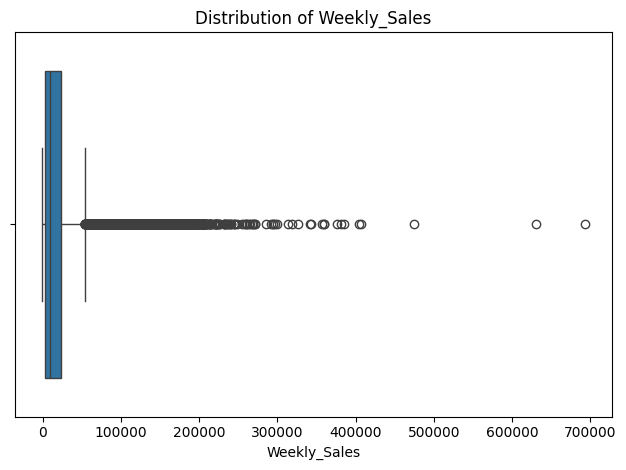

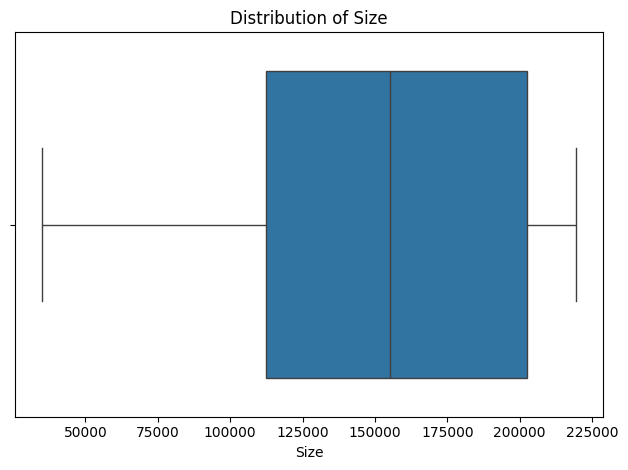

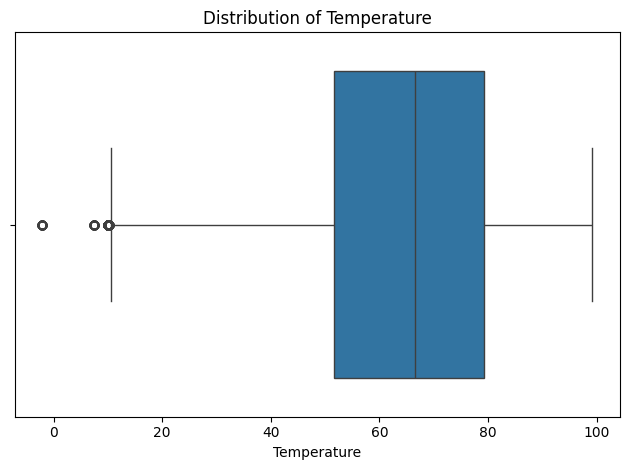

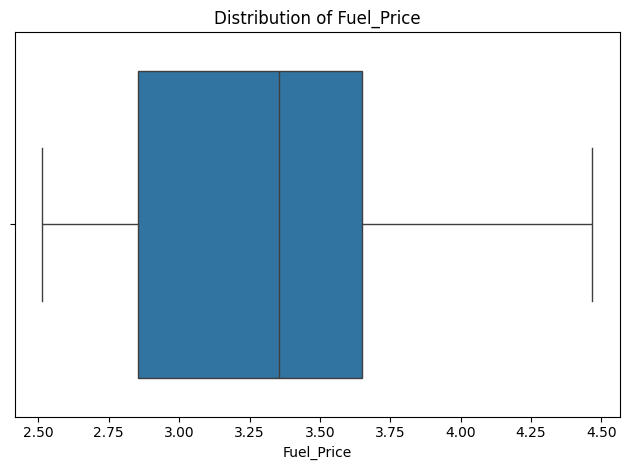

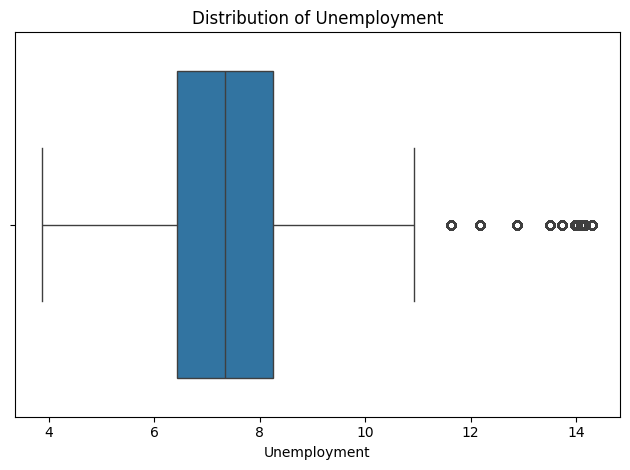

In [26]:
def plot_boxplots(df, cols):
    for col in cols:
        # Check if the column has any non-null values before plotting
        if not df[col].dropna().empty:
            fig, ax = plt.subplots()
            sns.boxplot(data=df, x=col, ax=ax)
            ax.set_title(f"Distribution of {col}")
            plt.tight_layout()
            plt.show()
        else:
            print(f"Skipping boxplot for '{col}' as it contains only NaN values.")

plot_boxplots(train, COLS_TO_VISUALIZE)

In [27]:
def describe_outliers(df, cols):
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR    = Q3 - Q1
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        print("=" * 40)
        print(f"Column              : {col}")
        print(f"Lower Bound         : {lower:.2f}")
        print(f"Upper Bound         : {upper:.2f}")
        print(f"Outliers Above Upper: {(df[col] > upper).sum()}")
        print(f"Outliers Below Lower: {(df[col] < lower).sum()}")

numeric_cols = train.select_dtypes(include='number').columns.tolist()
describe_outliers(train, numeric_cols)

Column              : Store
Lower Bound         : -6.50
Upper Bound         : 21.50
Outliers Above Upper: 0
Outliers Below Lower: 0
Column              : Dept
Lower Bound         : -59.00
Upper Bound         : 149.00
Outliers Above Upper: 0
Outliers Below Lower: 0
Column              : Weekly_Sales
Lower Bound         : -28268.04
Upper Bound         : 54469.23
Outliers Above Upper: 12357
Outliers Below Lower: 0
Column              : Size
Lower Bound         : -23162.50
Upper Bound         : 337905.50
Outliers Above Upper: 0
Outliers Below Lower: 0
Column              : Temperature
Lower Bound         : 10.40
Upper Bound         : 120.45
Outliers Above Upper: 0
Outliers Below Lower: 341
Column              : Fuel_Price
Lower Bound         : 1.66
Upper Bound         : 4.85
Outliers Above Upper: 0
Outliers Below Lower: 0
Column              : MarkDown1
Lower Bound         : -7522.38
Upper Bound         : 20786.34
Outliers Above Upper: 2992
Outliers Below Lower: 0
Column              : Mar

## 6. Preprocessing

In [28]:
HIGH_PRIORITY_FILL_ZERO = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
HIGH_PRIORITY_FILL_MEDIAN = ['CPI', 'Unemployment']

def fill_missing(df):
    """Fill high-priority missing values:
    - MarkDown1-5: fill with 0 (no promotion = no markdown)
    - CPI, Unemployment: fill with 0 as instructed
    - IsHoliday: fill with False (assuming NaN means not a holiday)
    """
    df = df.copy()
    # MarkDown columns: 0 means no markdown event occurred
    df[HIGH_PRIORITY_FILL_ZERO] = df[HIGH_PRIORITY_FILL_ZERO].fillna(0)
    # CPI & Unemployment: fill with 0
    df[HIGH_PRIORITY_FILL_MEDIAN] = df[HIGH_PRIORITY_FILL_MEDIAN].fillna(0)
    # IsHoliday: fill with False, then explicitly cast to bool
    df['IsHoliday'] = df['IsHoliday'].fillna(False).astype(bool)
    return df

def date_features(df):
    df = df.copy()
    df['Date']  = pd.to_datetime(df['Date'])
    df['Year']  = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day']   = df['Date'].dt.day
    df['Week']  = df['Date'].dt.isocalendar().week.astype(int)
    return df.drop(columns=['Date'])

def remove_outliers(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR    = Q3 - Q1
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

def change_types(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Type']      = df['Type'].map({"A":0, "B":1, "C":2}).astype(int)
    df['IsHoliday'] = df['IsHoliday'].astype(int)
    df['CPI']       = df['CPI'].round(2)
    return df

def preprocess(df):
    df = fill_missing(df)
    df = date_features(df)
    df = remove_outliers(df, df.select_dtypes(include='number').columns.tolist())
    df = change_types(df)
    return df

train = preprocess(train)
test  = preprocess(test)


In [29]:
# Verify: no missing values remain in high-priority columns
high_priority = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                 'CPI', 'Unemployment']
missing_after = train[high_priority].isna().sum()
print("Missing values after preprocessing:")
print(missing_after.to_string())
print()
print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Missing values after preprocessing:
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0

Train shape: (139088, 19)
Test shape : (115064, 18)


,Store,Dept,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Day,Week
0,1,1,24924.50,0,0,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.10,8.106,2010,2,5,5
1,1,1,46039.49,1,0,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.24,8.106,2010,2,12,6
2,1,1,41595.55,0,0,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.29,8.106,2010,2,19,7
3,1,1,19403.54,0,0,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.32,8.106,2010,2,26,8
4,1,1,21827.90,0,0,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.35,8.106,2010,3,5,9


## 7. Visualizations

End-to-end visual analysis of the Walmart dataset across 15 questions.


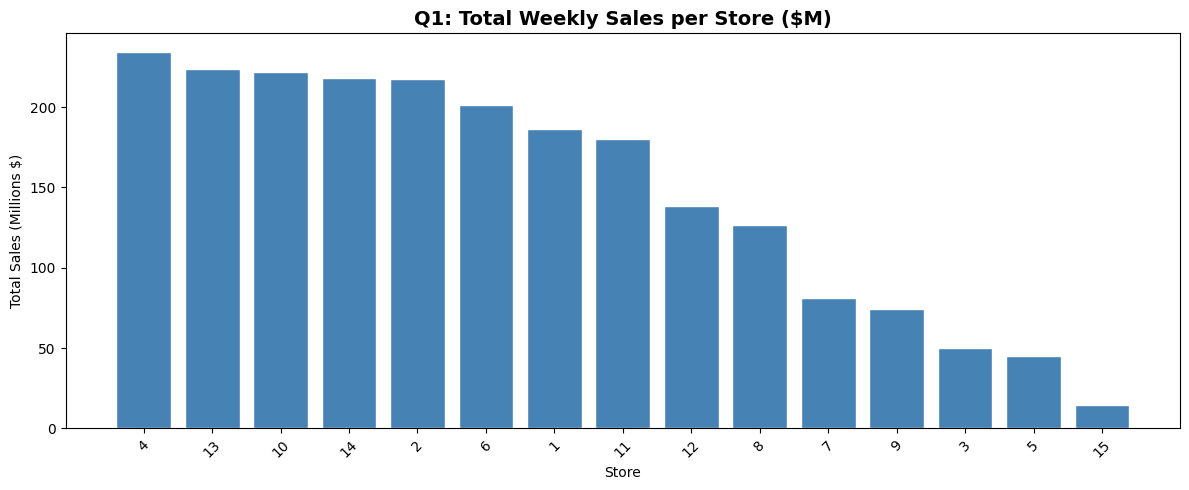

Answer: Top store is Store 4.0 with total $234.33M


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# Q1: Total Weekly Sales per Store
# ─────────────────────────────────────────────────────────────────────────────
top_stores = train.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).reset_index()
top_stores.columns = ['Store', 'Total_Sales']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_stores['Store'].astype(str), top_stores['Total_Sales'] / 1e6,
       color='steelblue', edgecolor='white')
ax.set_title('Q1: Total Weekly Sales per Store ($M)', fontsize=14, fontweight='bold')
ax.set_xlabel('Store')
ax.set_ylabel('Total Sales (Millions $)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Answer: Top store is Store {top_stores.iloc[0]['Store']} "
      f"with total ${top_stores.iloc[0]['Total_Sales']/1e6:.2f}M")

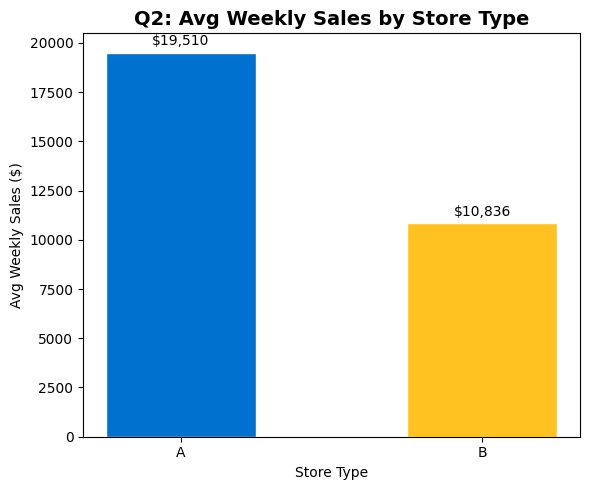

Type_Label  Avg_Weekly_Sales
         A      19510.177583
         B      10836.230331


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Q2: Average Weekly Sales by Store Type
# ─────────────────────────────────────────────────────────────────────────────
avg_by_type = train.groupby('Type')['Weekly_Sales'].mean().reset_index()
avg_by_type.columns = ['Type', 'Avg_Weekly_Sales']
type_labels = {0: 'A', 1: 'B', 2: 'C'}
avg_by_type['Type_Label'] = avg_by_type['Type'].map(type_labels)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(avg_by_type['Type_Label'], avg_by_type['Avg_Weekly_Sales'],
              color=['#0071CE', '#FFC220', '#E31837'], width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=10)
ax.set_title('Q2: Avg Weekly Sales by Store Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Store Type')
ax.set_ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()
print(avg_by_type[['Type_Label', 'Avg_Weekly_Sales']].to_string(index=False))


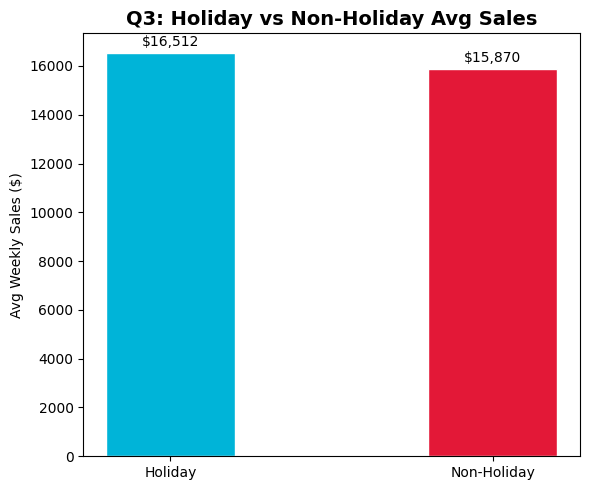

Answer: Holiday sales are higher by $642.92 on average


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Q3: Holiday vs Non-Holiday Average Sales
# ─────────────────────────────────────────────────────────────────────────────
holiday_map = {0: 'Non-Holiday', 1: 'Holiday'}
train['Holiday_Label'] = train['IsHoliday'].map(holiday_map)
avg_holiday = train.groupby('Holiday_Label')['Weekly_Sales'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(avg_holiday.index, avg_holiday.values,
              color=['#00B4D8', '#E31837'], width=0.4, edgecolor='white')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=10)
ax.set_title('Q3: Holiday vs Non-Holiday Avg Sales', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()
diff = avg_holiday['Holiday'] - avg_holiday['Non-Holiday']
print(f"Answer: Holiday sales are higher by ${diff:,.2f} on average")


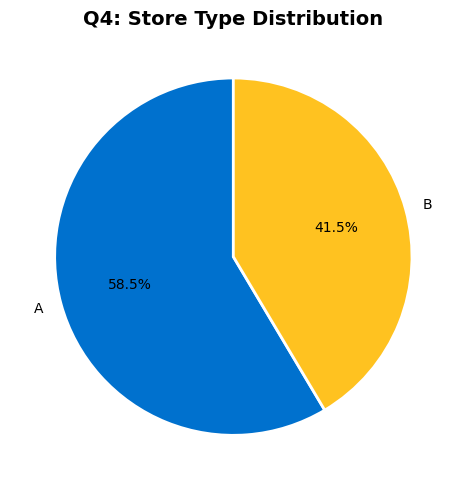

Answer: Most common type is Type 'A' with 81,436 records


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Q4: Store Type Distribution
# ─────────────────────────────────────────────────────────────────────────────
type_counts = train['Type'].map({0: 'A', 1: 'B', 2: 'C'}).value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.1f%%', colors=['#0071CE', '#FFC220', '#E31837'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Q4: Store Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Answer: Most common type is Type '{type_counts.idxmax()}' with {type_counts.max():,} records")

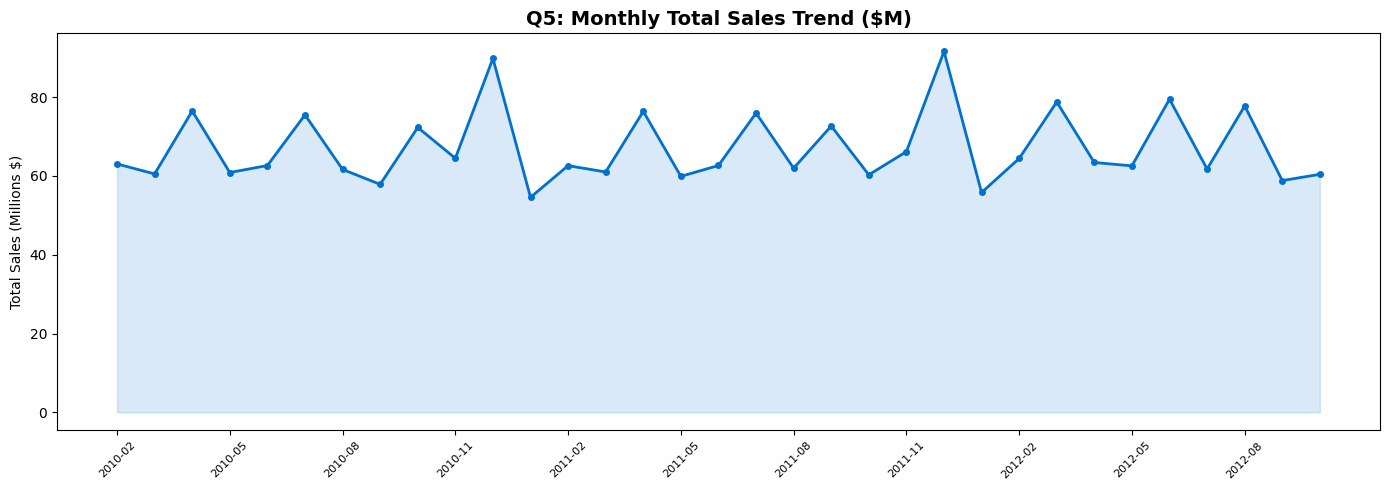

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Q5: Monthly Total Sales Trend
# ─────────────────────────────────────────────────────────────────────────────
train['YearMonth'] = train['Year'].astype(str) + '-' + train['Month'].astype(str).str.zfill(2)
monthly = train.groupby('YearMonth')['Weekly_Sales'].sum().reset_index().sort_values('YearMonth')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly)), monthly['Weekly_Sales'] / 1e6,
        color='#0071CE', linewidth=2, marker='o', markersize=4)
ax.fill_between(range(len(monthly)), monthly['Weekly_Sales'] / 1e6, alpha=0.15, color='#0071CE')
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly['YearMonth'].iloc[::3], rotation=45, fontsize=8)
ax.set_title('Q5: Monthly Total Sales Trend ($M)', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales (Millions $)')
plt.tight_layout()
plt.show()


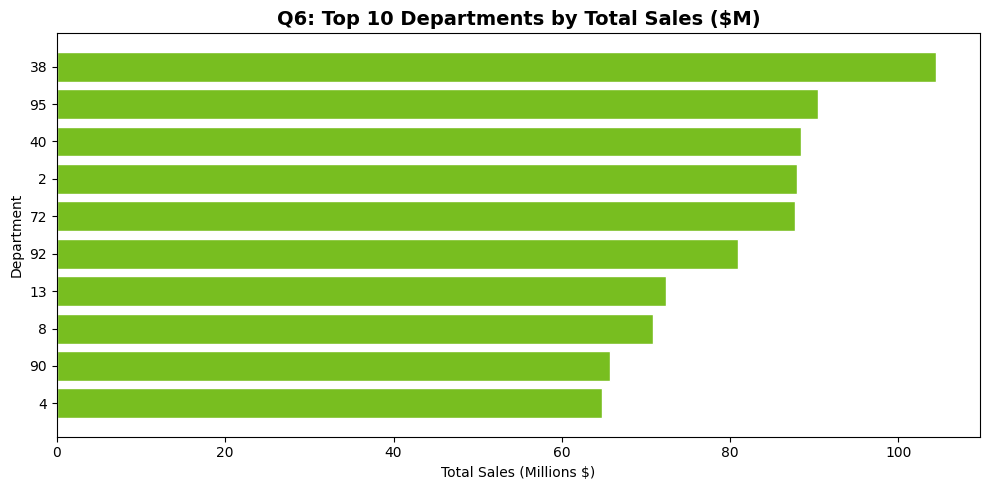

Answer: Top department is Dept 38.0 with $104.47M


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Q6: Top 10 Departments by Total Sales
# ─────────────────────────────────────────────────────────────────────────────
top_depts = train.groupby('Dept')['Weekly_Sales'].sum().nlargest(10).reset_index()
top_depts.columns = ['Dept', 'Total_Sales']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_depts['Dept'].astype(str), top_depts['Total_Sales'] / 1e6,
        color='#78BE20', edgecolor='white')
ax.set_title('Q6: Top 10 Departments by Total Sales ($M)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (Millions $)')
ax.set_ylabel('Department')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"Answer: Top department is Dept {top_depts.iloc[0]['Dept']} "
      f"with ${top_depts.iloc[0]['Total_Sales']/1e6:.2f}M")

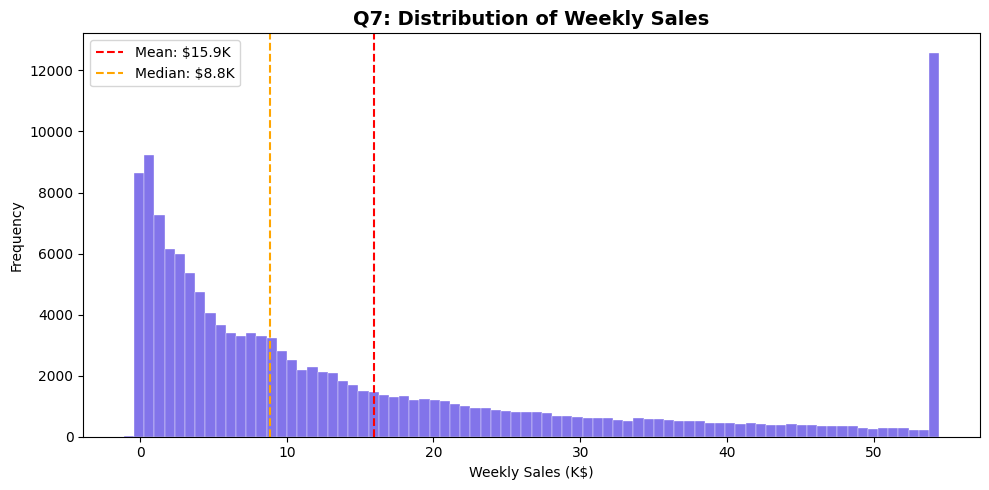

Mean  : $15,914.82
Median: $8,843.74
Std   : $17,177.69


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Q7: Distribution of Weekly Sales
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train['Weekly_Sales'] / 1000, bins=80, color='#6C5CE7',
        edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(train['Weekly_Sales'].mean() / 1000, color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: ${train['Weekly_Sales'].mean()/1000:.1f}K")
ax.axvline(train['Weekly_Sales'].median() / 1000, color='orange', linestyle='--', linewidth=1.5,
           label=f"Median: ${train['Weekly_Sales'].median()/1000:.1f}K")
ax.set_title('Q7: Distribution of Weekly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Weekly Sales (K$)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mean  : ${train['Weekly_Sales'].mean():,.2f}")
print(f"Median: ${train['Weekly_Sales'].median():,.2f}")
print(f"Std   : ${train['Weekly_Sales'].std():,.2f}")


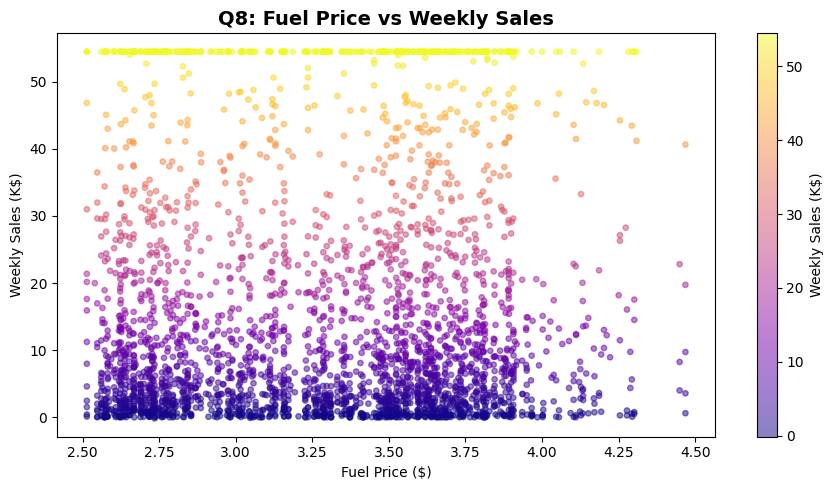

Correlation between Fuel_Price and Weekly_Sales: 0.0254


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Q8: Fuel Price vs Weekly Sales
# ─────────────────────────────────────────────────────────────────────────────
sample = train.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(sample['Fuel_Price'], sample['Weekly_Sales'] / 1000,
                c=sample['Weekly_Sales'] / 1000, cmap='plasma', alpha=0.5, s=15)
plt.colorbar(sc, ax=ax, label='Weekly Sales (K$)')
ax.set_title('Q8: Fuel Price vs Weekly Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Fuel Price ($)')
ax.set_ylabel('Weekly Sales (K$)')
plt.tight_layout()
plt.show()
corr = train['Fuel_Price'].corr(train['Weekly_Sales'])
print(f"Correlation between Fuel_Price and Weekly_Sales: {corr:.4f}")

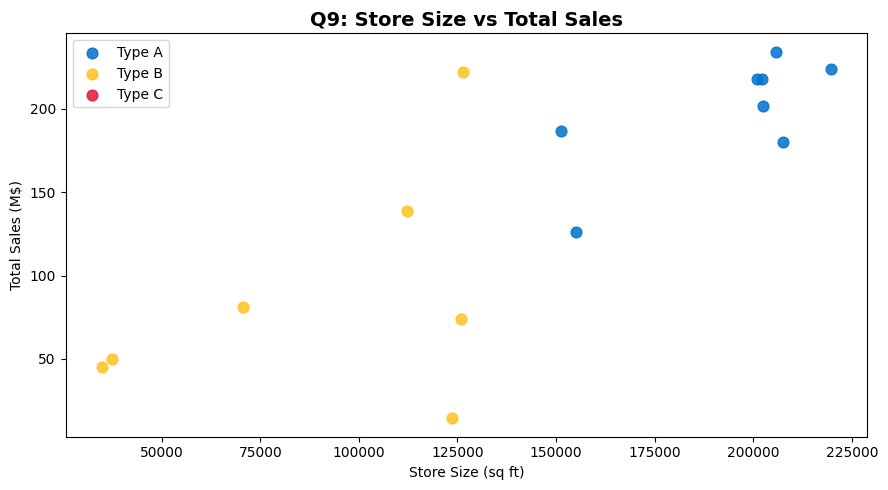

Correlation between Size and Total_Sales: 0.8061


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# Q9: Store Size vs Total Sales
# ─────────────────────────────────────────────────────────────────────────────
store_summary = train.groupby('Store').agg(
    Total_Sales=('Weekly_Sales', 'sum'),
    Size=('Size', 'first'),
    Type=('Type', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for t, label, c in zip([0, 1, 2], ['Type A', 'Type B', 'Type C'],
                        ['#0071CE', '#FFC220', '#E31837']):
    s = store_summary[store_summary['Type'] == t]
    ax.scatter(s['Size'], s['Total_Sales'] / 1e6, color=c, label=label, s=60, alpha=0.85)
ax.set_title('Q9: Store Size vs Total Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Store Size (sq ft)')
ax.set_ylabel('Total Sales (M$)')
ax.legend()
plt.tight_layout()
plt.show()
corr2 = store_summary['Size'].corr(store_summary['Total_Sales'])
print(f"Correlation between Size and Total_Sales: {corr2:.4f}")


/tmp/ipykernel_12000/287965406.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_groups, labels=['A', 'B', 'C'], patch_artist=True)


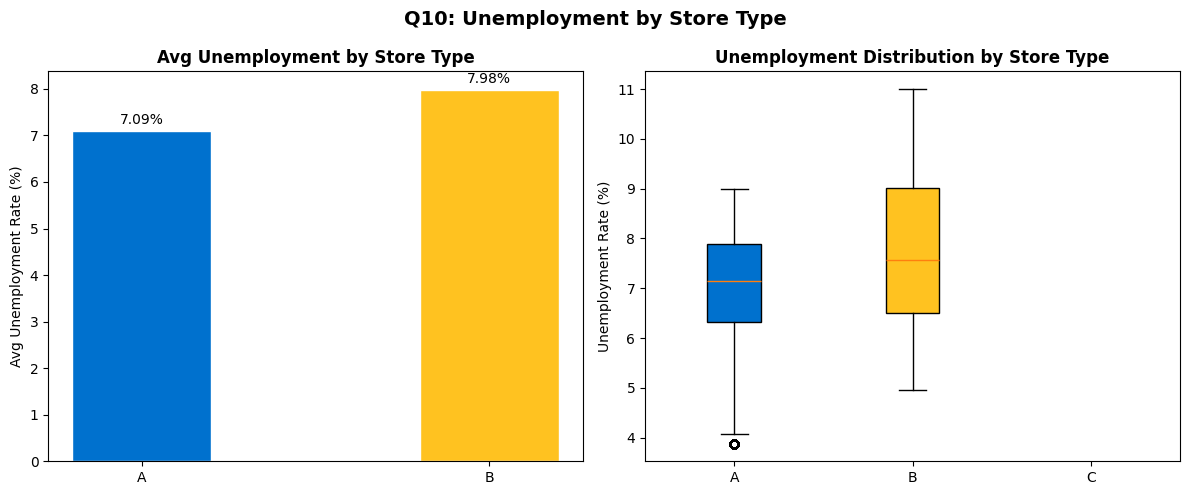

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# Q10: Unemployment by Store Type
# ─────────────────────────────────────────────────────────────────────────────
unemp_by_type = train.groupby('Type')['Unemployment'].mean().reset_index()
unemp_by_type['Type_Label'] = unemp_by_type['Type'].map({0: 'A', 1: 'B', 2: 'C'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = axes[0].bar(unemp_by_type['Type_Label'], unemp_by_type['Unemployment'],
                   color=['#0071CE', '#FFC220', '#E31837'], width=0.4, edgecolor='white')
axes[0].bar_label(bars, fmt='%.2f%%', padding=3)
axes[0].set_title('Avg Unemployment by Store Type', fontweight='bold')
axes[0].set_ylabel('Avg Unemployment Rate (%)')

data_groups = [train[train['Type'] == t]['Unemployment'].values for t in [0, 1, 2]]
bp = axes[1].boxplot(data_groups, labels=['A', 'B', 'C'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#0071CE', '#FFC220', '#E31837']):
    patch.set_facecolor(color)
axes[1].set_title('Unemployment Distribution by Store Type', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
plt.suptitle('Q10: Unemployment by Store Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


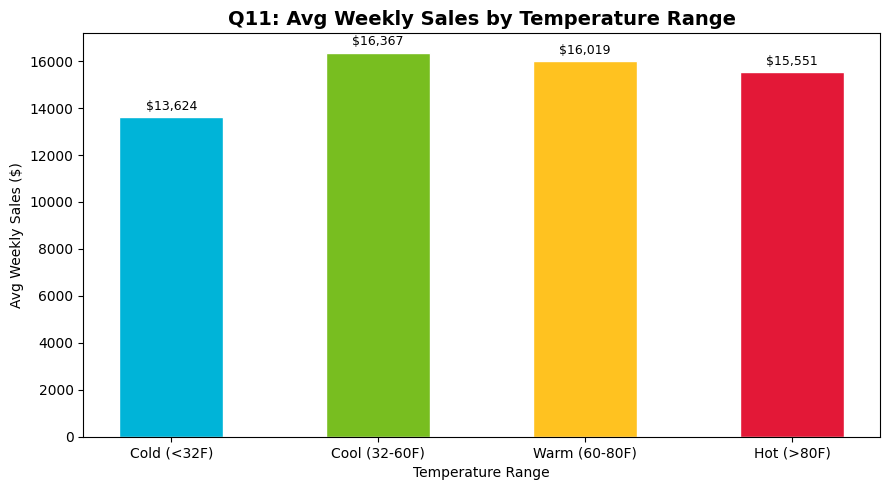

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# Q11: Avg Weekly Sales by Temperature Range
# ─────────────────────────────────────────────────────────────────────────────
train['Temp_Bin'] = pd.cut(train['Temperature'],
                           bins=[0, 32, 60, 80, 120],
                           labels=['Cold (<32F)', 'Cool (32-60F)', 'Warm (60-80F)', 'Hot (>80F)'])
temp_sales = train.groupby('Temp_Bin', observed=True)['Weekly_Sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(temp_sales['Temp_Bin'], temp_sales['Weekly_Sales'],
              color=['#00B4D8', '#78BE20', '#FFC220', '#E31837'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
ax.set_title('Q11: Avg Weekly Sales by Temperature Range', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature Range')
ax.set_ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.show()

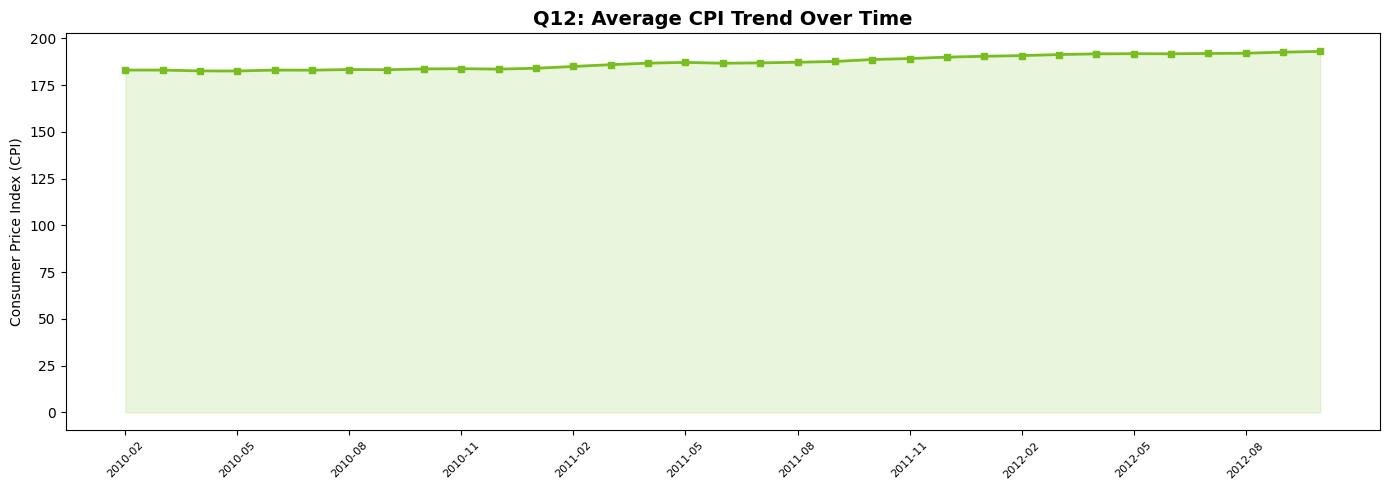

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# Q12: Average CPI Trend Over Time
# ─────────────────────────────────────────────────────────────────────────────
cpi_trend = train.groupby('YearMonth')['CPI'].mean().reset_index().sort_values('YearMonth')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(cpi_trend)), cpi_trend['CPI'],
        color='#78BE20', linewidth=2, marker='s', markersize=4)
ax.fill_between(range(len(cpi_trend)), cpi_trend['CPI'], alpha=0.15, color='#78BE20')
ax.set_xticks(range(0, len(cpi_trend), 3))
ax.set_xticklabels(cpi_trend['YearMonth'].iloc[::3], rotation=45, fontsize=8)
ax.set_title('Q12: Average CPI Trend Over Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Consumer Price Index (CPI)')
plt.tight_layout()
plt.show()

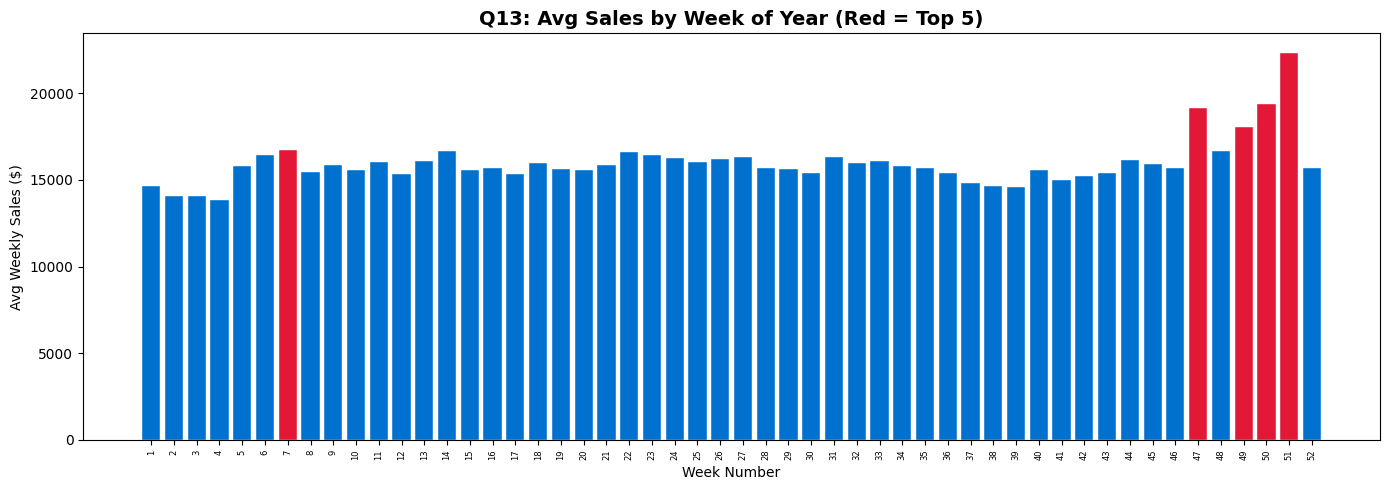

Top 5 highest-sales weeks:
 Week  Weekly_Sales
   51  22340.675807
   50  19409.385043
   47  19161.199966
   49  18081.341505
    7  16752.640757


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Q13: Avg Sales by Week of Year
# ─────────────────────────────────────────────────────────────────────────────
weekly_avg = train.groupby('Week')['Weekly_Sales'].mean().reset_index()
weekly_avg = weekly_avg.sort_values('Weekly_Sales', ascending=False)
sorted_weekly = weekly_avg.sort_values('Week')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(sorted_weekly['Week'].astype(str), sorted_weekly['Weekly_Sales'],
       color=['#E31837' if w in weekly_avg.head(5)['Week'].values else '#0071CE'
              for w in sorted_weekly['Week']],
       edgecolor='white', linewidth=0.3)
ax.set_title('Q13: Avg Sales by Week of Year (Red = Top 5)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week Number')
ax.set_ylabel('Avg Weekly Sales ($)')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()
print('Top 5 highest-sales weeks:')
print(weekly_avg.head(5).to_string(index=False))


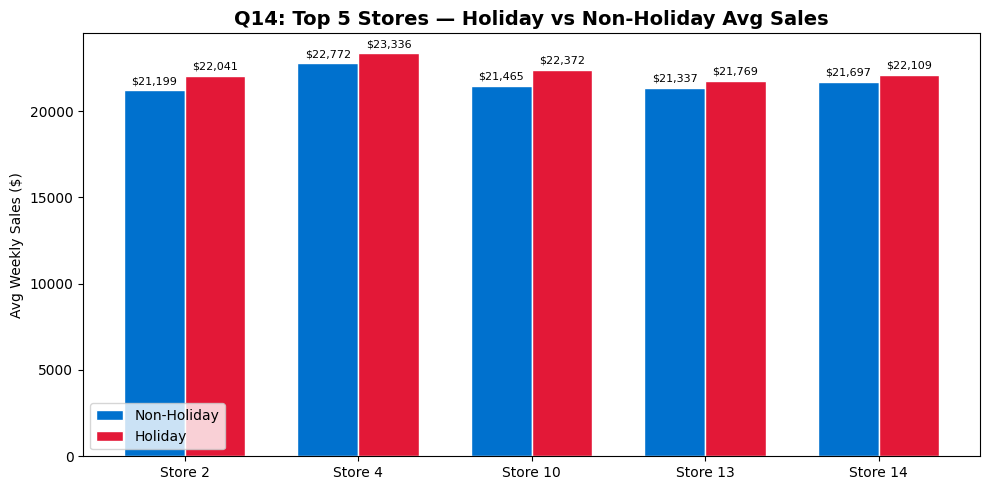

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Q14: Top 5 Stores — Holiday vs Non-Holiday Avg Sales
# ─────────────────────────────────────────────────────────────────────────────
top5 = train.groupby('Store')['Weekly_Sales'].sum().nlargest(5).index
df_top5 = train[train['Store'].isin(top5)]
pivot = df_top5.groupby(['Store', 'IsHoliday'])['Weekly_Sales'].mean().unstack()
pivot.columns = ['Non-Holiday', 'Holiday']
pivot.index = [f'Store {s}' for s in pivot.index]

x = range(len(pivot))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - w/2 for i in x], pivot['Non-Holiday'], w,
               label='Non-Holiday', color='#0071CE', edgecolor='white')
bars2 = ax.bar([i + w/2 for i in x], pivot['Holiday'], w,
               label='Holiday', color='#E31837', edgecolor='white')
ax.bar_label(bars1, fmt='${:,.0f}', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='${:,.0f}', padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index)
ax.set_title('Q14: Top 5 Stores — Holiday vs Non-Holiday Avg Sales',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Weekly Sales ($)')
ax.legend()
plt.tight_layout()
plt.show()

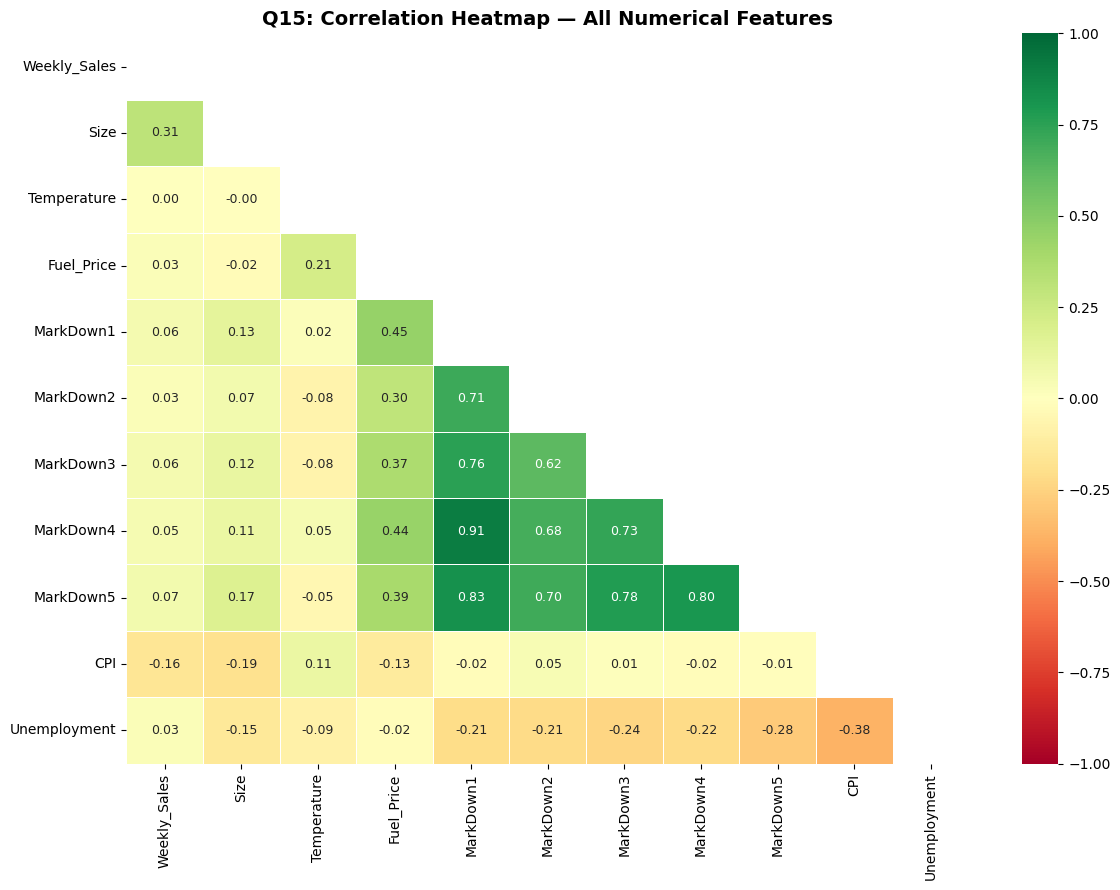

Top correlations with Weekly_Sales:
Size         0.312048
CPI          0.162895
MarkDown5    0.070075
MarkDown1    0.061650
MarkDown3    0.058140


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Q15: Correlation Heatmap
# ─────────────────────────────────────────────────────────────────────────────
corr_cols = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
             'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
             'CPI', 'Unemployment']
corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Q15: Correlation Heatmap — All Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_corr = corr_matrix['Weekly_Sales'].drop('Weekly_Sales').abs().sort_values(ascending=False)
print('Top correlations with Weekly_Sales:')
print(top_corr.head(5).to_string())
